In [ ]:
!pip install qiskit
!pip install pylatexenc
!pip install aqora_cli
!pip install qiskit-algorithms

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import os
from google.colab import files
from qiskit_algorithms.optimizers import SPSA

In [ ]:
files.upload()
os.listdir()

Saving Problem A Dataset.parquet to Problem A Dataset (1).parquet


['.config',
 'Problem A Dataset (1).parquet',
 'Problem A Dataset.parquet',
 'sample_data']

In [ ]:
df = pd.read_parquet("Problem A Dataset.parquet")

df['node_1'] = df['node_1'].astype(int)
df['node_2'] = df['node_2'].astype(int)

# Normalize the Weights
max_weight = df['weight'].max()
df['weight'] = df['weight'] / max_weight

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   node_1  28 non-null     int64  
 1   node_2  28 non-null     int64  
 2   weight  28 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 804.0 bytes


In [ ]:
# Display the first 5 rows of the DataFrame to inspect its structure and content.
df.head()

,node_1,node_2,weight
0,3,13,0.175954
1,3,16,0.189590
2,2,5,1.000000
3,5,14,0.109292
4,5,20,0.207898


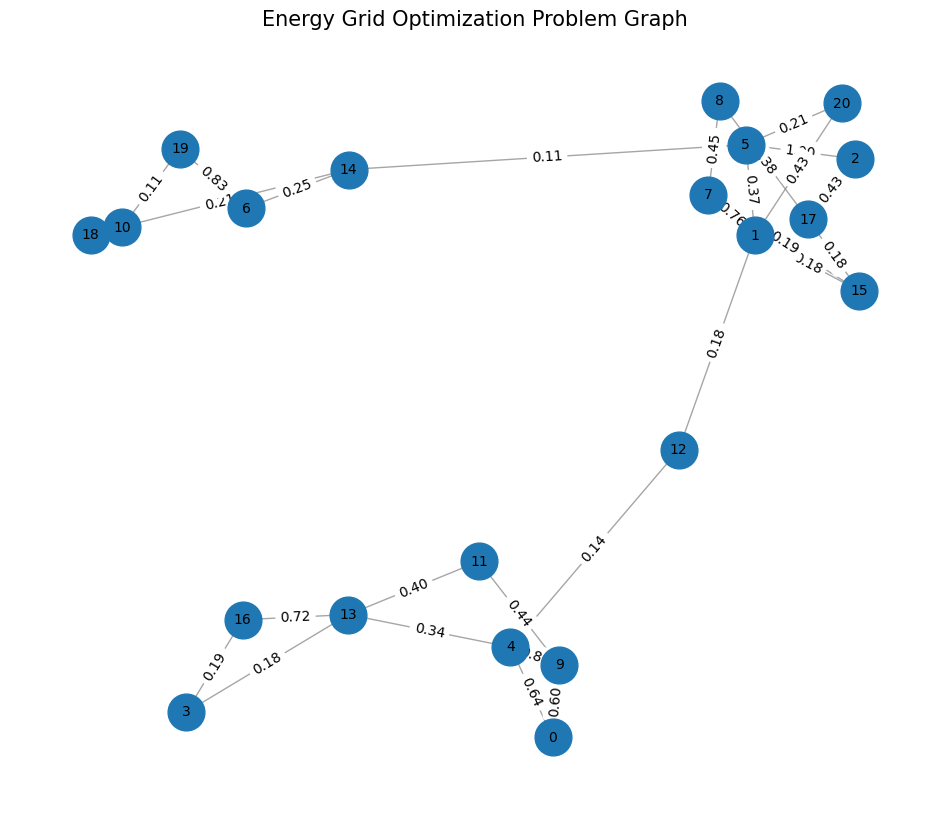

In [ ]:
G = nx.from_pandas_edgelist(
    df,
    source='node_1',
    target='node_2',
    edge_attr='weight'
)

# Set up the plot
plt.figure(figsize=(12, 10))

# Set a random_state for reproducible layout
pos = nx.spring_layout(G, k=0.15, iterations=20) # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_size=700)
nx.draw_networkx_edges(G, pos, width=1, alpha=0.7, edge_color='gray')

# Add edge labels (weights)
edge_labels = nx.get_edge_attributes(G, 'weight')
# Format labels to be more readable if there are many decimal places
formatted_edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)

# Add node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

plt.title('Energy Grid Optimization Problem Graph', size=15)
plt.axis('off') # Hide axes
plt.show()

In [ ]:
nodes = sorted(G.nodes())
print('Nodes is ' + str(nodes))
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Sample edge with weight:", list(G.edges(data=True))[:3])

Nodes is [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Number of nodes: 21
Number of edges: 28
Sample edge with weight: [(3, 13, {'weight': 0.17595394829769584}), (3, 16, {'weight': 0.18959029427520815}), (13, 4, {'weight': 0.34325883332505774})]


In [ ]:
node_to_index = {node: i for i, node in enumerate(nodes)}
print(node_to_index)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20}


In [ ]:
for u, v, w in G.edges(data=True):
    print(u, v, w['weight'])
    break

3 13 0.17595394829769584


In [ ]:
def compute_cut_value(G, bitstring):
    cut_value = 0

    for u, v, data in G.edges(data=True):
        if bitstring[u] != bitstring[v]:
            cut_value += data['weight']

    return cut_value


random_partition = [random.randint(0,1) for _ in range(len(G.nodes()))]

print("Random partition:", random_partition)
print("Cut value:", compute_cut_value(G, random_partition))

Random partition: [0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1]
Cut value: 4.727319856429219


In [ ]:
# See random max-cut values
for _ in range(10):
    random_partition = [random.randint(0,1) for _ in range(len(G.nodes()))]
    print(compute_cut_value(G, random_partition))

# Calculate total weight of the graph
total_weight = sum(data['weight'] for _,_,data in G.edges(data=True))
print("---------------------------------------------------")
print('total weight is: ' + str(total_weight))

5.33193668433614
7.4398454715984235
5.100573624326729
6.277953697349182
5.597674836863442
6.335854121072443
5.814217094302797
4.84056131383272
6.987775049903961
6.165339371131524
---------------------------------------------------
total weight is: 11.015054146292533


In [ ]:
import itertools

def brute_force_maxcut(G):
    n = len(G.nodes())
    best_value = 0
    best_partition = None

    for bits in itertools.product([0,1], repeat=n):
        val = compute_cut_value(G, bits)
        if val > best_value:
            best_value = val
            best_partition = bits

    return best_value, best_partition

best_val, best_part = brute_force_maxcut(G)
print("Optimal cut value:", best_val)

Optimal cut value: 9.741919446283418


In [ ]:
def performance_ratio(obtained, optimal):
    return obtained / optimal
print("Random performance ratio:",
      performance_ratio(3000, best_val))

Random performance ratio: 307.9475268238347


In [ ]:
def expectation_from_samples(G, samples):
    total = 0
    for bitstring in samples:
        total += compute_cut_value(G, bitstring)
    return total / len(samples)

samples = [
    [random.randint(0,1) for _ in range(len(G.nodes()))]
    for _ in range(100)
]

print("Average random expectation:",
      expectation_from_samples(G, samples))

Average random expectation: 5.542728225089853


# QAOA Implementation

In [ ]:
num_qubits = len(G.nodes())
pauli_list = []
coeffs = []

for u, v, data in G.edges(data=True):
    i = node_to_index[u]
    j = node_to_index[v]
    w = data['weight']

    # string of I's
    pauli = ['I'] * num_qubits
    pauli[i] = 'Z'
    pauli[j] = 'Z'

    pauli_str = ''.join(pauli)

    pauli_list.append(pauli_str)
    coeffs.append(-0.5 * w)  # from (1 - Z_i Z_j)/2 → will keep only -0.5 w Z_i Z_j

print("First 5 Pauli strings:", pauli_list[:5])
print("First 5 coefficients:", coeffs[:5])

First 5 Pauli strings: ['IIIZIIIIIIIIIZIIIIIII', 'IIIZIIIIIIIIIIIIZIIII', 'IIIIZIIIIIIIIZIIIIIII', 'IIIIIIIIIIIIIZIIZIIII', 'IIIIIIIIIIIZIZIIIIIII']
First 5 coefficients: [-0.08797697414884792, -0.09479514713760408, -0.17162941666252887, -0.35934807116279444, -0.1994417891495485]


In [ ]:
# the Cost Hamiltonian
cost_hamiltonian = SparsePauliOp(pauli_list, coeffs)

print(cost_hamiltonian)
print("Number of terms:", len(cost_hamiltonian))

SparsePauliOp(['IIIZIIIIIIIIIZIIIIIII', 'IIIZIIIIIIIIIIIIZIIII', 'IIIIZIIIIIIIIZIIIIIII', 'IIIIIIIIIIIIIZIIZIIII', 'IIIIIIIIIIIZIZIIIIIII', 'IIZIIZIIIIIIIIIIIIIII', 'IIZIIIIIIIIIIIIIIZIII', 'IIIIIZIIIIIIIIZIIIIII', 'IIIIIZIIIIIIIIIIIIIIZ', 'IZIIIZIIIIIIIIIIIIIII', 'IIIIIIZIIIIIIIZIIIIII', 'IIIIIIIIIIIIIIZIIIZII', 'IZIIIIIIIIIIIIIIIIIIZ', 'IZIIIIIIIIIIZIIIIIIII', 'IZIIIIIIIIIIIIIZIIIII', 'IZIIIIIZIIIIIIIIIIIII', 'IIIIIIIZZIIIIIIIIIIII', 'IIIIIIIZIIIIIIIZIIIII', 'IIIIIIIIZIIIIIIIIZIII', 'IIIIIIIIIIIIIIIZIZIII', 'IIIIIIIIIIZIIIIIIIIZI', 'IIIIIIIIIIZIIIIIIIZII', 'IIIIIIZIIIIIIIIIIIIZI', 'ZIIIZIIIIIIIIIIIIIIII', 'ZIIIIIIIIZIIIIIIIIIII', 'IIIIZIIIIZIIIIIIIIIII', 'IIIIZIIIIIIIZIIIIIIII', 'IIIIIIIIIZIZIIIIIIIII'],
              coeffs=[-0.08797697+0.j, -0.09479515+0.j, -0.17162942+0.j, -0.35934807+0.j,
 -0.19944179+0.j, -0.5       +0.j, -0.21670992+0.j, -0.05464585+0.j,
 -0.10394879+0.j, -0.18503343+0.j, -0.12505108+0.j, -0.10626095+0.j,
 -0.21268561+0.j, -0.09175149+0.j, -0.09062896+0.j, -0.3

In [ ]:
# the Cicuit
num_qubits = len(G.nodes())

def create_qaoa_circuit(params):
    qc = QuantumCircuit(num_qubits)

    # Initial superposition
    for i in range(num_qubits):
        qc.x(i)
        qc.h(i)

    p = len(params) // 2

    for layer in range(p):
        gamma = params[2*layer]
        beta  = params[2*layer + 1]

        # Cost layer
        for pauli, coeff in zip(pauli_list, coeffs):
            z_indices = [i for i, pz in enumerate(pauli) if pz == 'Z']
            i, j = z_indices
            theta = 2 * gamma * coeff.real
            qc.rzz(theta, i, j)

        # Mixer layer
        for i in range(num_qubits):
            qc.rx(2 * beta, i)

    return qc

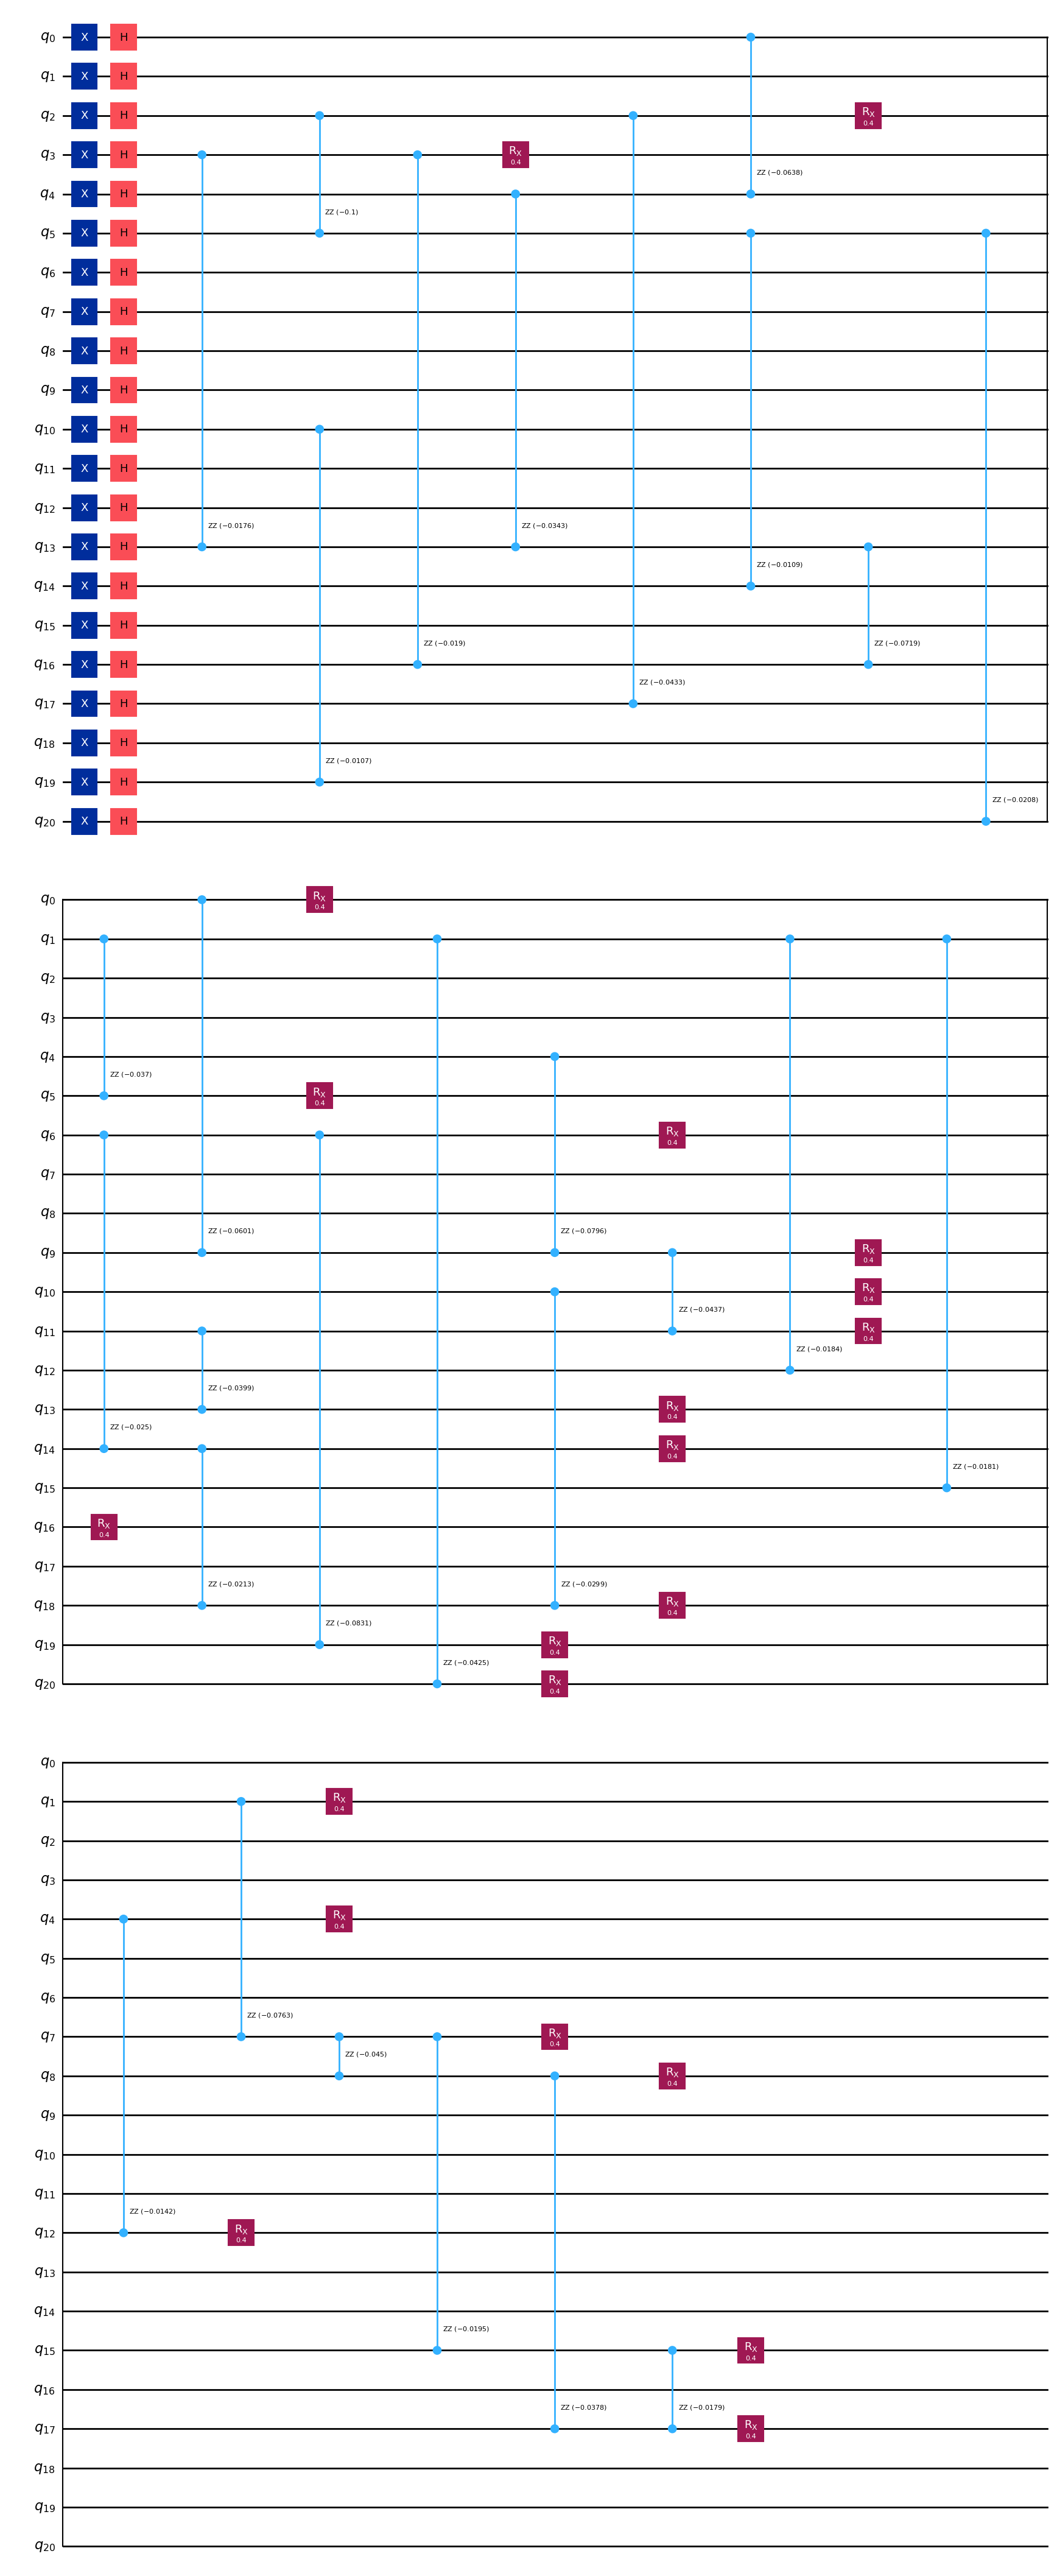

In [ ]:
qc = create_qaoa_circuit([0.1, 0.2])
qc.draw('mpl', style='iqp')

In [ ]:
estimator = StatevectorEstimator()

def compute_expectation(params):
    qc = create_qaoa_circuit(params)

    job = estimator.run(
        pubs=[(qc, cost_hamiltonian)]
    )

    result = job.result()

    value = result[0].data.evs

    return value

val = compute_expectation([0.1, 0.2, 0.1, 0.2])
print("Expectation value:", val)

Expectation value: 0.0193767069931249


In [ ]:
total_weight = sum(data['weight'] for _,_,data in G.edges(data=True))
half_total = total_weight / 2

print("Total weight:", total_weight)
print("Half of total weight:", half_total)

Total weight: 11.015054146292533
Half of total weight: 5.507527073146266


In [ ]:
def objective(params):
    return -compute_expectation(params)

num_starts = 10
best_value = -1e9
best_result = None

for run in range(num_starts):

    initial_guess = np.random.uniform(0, 2*np.pi, 4)

    result = minimize(
        objective,
        initial_guess,
        method="COBYLA",
        options={"maxiter": 200}
    )

    value = -result.fun

    print(f"Run {run+1}: Expectation = {value}")

    if value > best_value:
        best_value = value
        best_result = result

print("\n===== BEST MULTI-START RESULT =====")
print("Best expectation:", best_value)
print("Best parameters:", best_result.x)

Run 1: Expectation = 0.20883179416887426
Run 2: Expectation = 0.13678402975561366
Run 3: Expectation = 0.19356689141382072
Run 4: Expectation = 0.16534177883987092
Run 5: Expectation = 0.13678343717187244
Run 6: Expectation = 0.1366771753983035
Run 7: Expectation = 0.13678675165057994
Run 8: Expectation = 0.19356688530643118
Run 9: Expectation = 0.07308480403754485
Run 10: Expectation = 0.16882324012139657

===== BEST MULTI-START RESULT =====
Best expectation: 0.20883179416887426
Best parameters: [ 3.00692786 -0.27703452  4.51515941  2.61038659]


In [ ]:
def evaluate_qaoa(params):
    # Calculate the Hamiltonian expectation value for the given QAOA parameters.
    # This value indicates how well the quantum state prepared by the QAOA circuit
    # aligns with the problem's objective function (Max-Cut in this case).
    h_val = compute_expectation(params)

    # Convert the Hamiltonian expectation value into a meaningful cut value for the graph.
    # For the Max-Cut problem, the cut value can be derived from the Hamiltonian expectation
    # using the relationship: Cut Value = (Total Edge Weight / 2) + Hamiltonian Expectation.
    # 'half_total' represents (Total Edge Weight / 2).
    cut_val = half_total + h_val

    # Calculate the performance ratio, which compares the obtained cut value
    # to the brute-force optimal cut value ('best_val').
    # A ratio closer to 1 indicates a better approximation to the optimal solution.
    ratio = cut_val / best_val

    # Return a dictionary containing the input parameters, the calculated Hamiltonian
    # expectation, the derived cut value, and the performance ratio.
    return {
        "parameters": params,
        "hamiltonian_expectation": h_val,
        "cut_value": cut_val,
        "performance_ratio": ratio
    }

In [ ]:
print("\n===== FINAL MULTI-START EVALUATION =====")

params = best_result.x
evaluation = evaluate_qaoa(params)

for k, v in evaluation.items():
    print(k, ":", v)


===== FINAL MULTI-START EVALUATION =====
parameters : [ 3.00692786 -0.27703452  4.51515941  2.61038659]
hamiltonian_expectation : 0.2088317941688742
cut_value : 5.71635886731514
performance_ratio : 0.5867795252090648
